1. Veriyi oku
2. column_summary tablosunu çıkar
3. text length analizi yap
4. product dağılımını gör
5. issue dağılımını gör
6. tags alanına bak
7. model_df oluştur
8. küçük sınıfları filtrele
9. processed CSV olarak kaydet

# 01 — CFPB Complaint Data: Initial EDA

# 03 — Baseline Product Classification

## Purpose

This notebook builds the first baseline machine learning model for complaint classification.

The task is:

Complaint narrative → Product category

We start with a simple and explainable baseline:

- TF-IDF vectorisation
- Logistic Regression classifier
- Train/test split
- Precision, recall, F1-score evaluation
- Confusion matrix review

This baseline will be used later to compare against transformer-based models such as DistilBERT.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
from pathlib import Path

processed_path = Path("../data/processed/cfpb_product_classification_sample.csv")
raw_path = Path("../data/raw/cfpb_complaints_narratives_1000.csv")

print("Processed exists:", processed_path.exists())
print("Raw exists:", raw_path.exists())

Processed exists: True
Raw exists: True


In [5]:
DATA_PATH = Path("../data/processed/cfpb_product_classification_sample.csv")

model_df = pd.read_csv(DATA_PATH)

print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

model_df.head()

Rows: 984
Columns: 2


,text,label
0,"This complaint concerns continued collection efforts relating to a disputed towing/storage deficiency balance allegedly owed to XXXX XXXX XXXX XXXX .\n\nAfter my original CFPB complaint, the colle...",Debt collection
1,"XXXX XXXX, the third-party company responsible for processing and disbursing student refunds on behalf of XXXX University , issued a direct deposit refund in the amount of approximately {$10000.00...",Checking or savings account
2,I received a call from XXXX XXXX impersonating an officer of the court with legal XXXX XXXX XXXX documents. They were attempting to come to my residents I contacted Citibank who had no record of d...,Debt collection
3,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, CA XXXX ( XXXX ) XXXX XXXX Date : XX/XX/XXXX Wells Fargo XXXX Department Re : Request for Reconsideration of Denied Debit Card Fraud Claim Claim Number : XXXX A...",Checking or savings account
4,"XXXX I need you XXXX XXXX, to put it in writing that you state that NO MONEY ( none of my money over the XXXX ) can be withdrawn from my Edge account for the XXXX Days after the NEW MONEY is depo...",Checking or savings account


# 03_baseline_classification.ipynb
## Siradaki Adimlar 
1. Classification datasını oku
2. label dağılımına bak
3. train/test split yap
4. TF-IDF ile metni sayıya çevir
5. Logistic Regression eğit
6. classification_report ile precision/recall/F1 ölç
7. confusion matrix ile model nerede karışıyor gör
8. sonuçları yorumla

In [6]:
label_counts = model_df["label"].value_counts()

print("Number of classes:", model_df["label"].nunique())
print("Total rows:", len(model_df))

label_counts

Number of classes: 8
Total rows: 984


label
Debt collection                                            299
Checking or savings account                                260
Credit card                                                209
Mortgage                                                    85
Vehicle loan or lease                                       49
Money transfer, virtual currency, or money service          31
Credit reporting or other personal consumer reports         28
Payday loan, title loan, personal loan, or advance loan     23
Name: count, dtype: int64

In [7]:
label_distribution = pd.DataFrame({
    "count": model_df["label"].value_counts(),
    "percent": (model_df["label"].value_counts(normalize=True) * 100).round(2)
})

label_distribution

,count,percent
label,,
Debt collection,299,30.39
Checking or savings account,260,26.42
Credit card,209,21.24
Mortgage,85,8.64
Vehicle loan or lease,49,4.98
"Money transfer, virtual currency, or money service",31,3.15
Credit reporting or other personal consumer reports,28,2.85
"Payday loan, title loan, personal loan, or advance loan",23,2.34


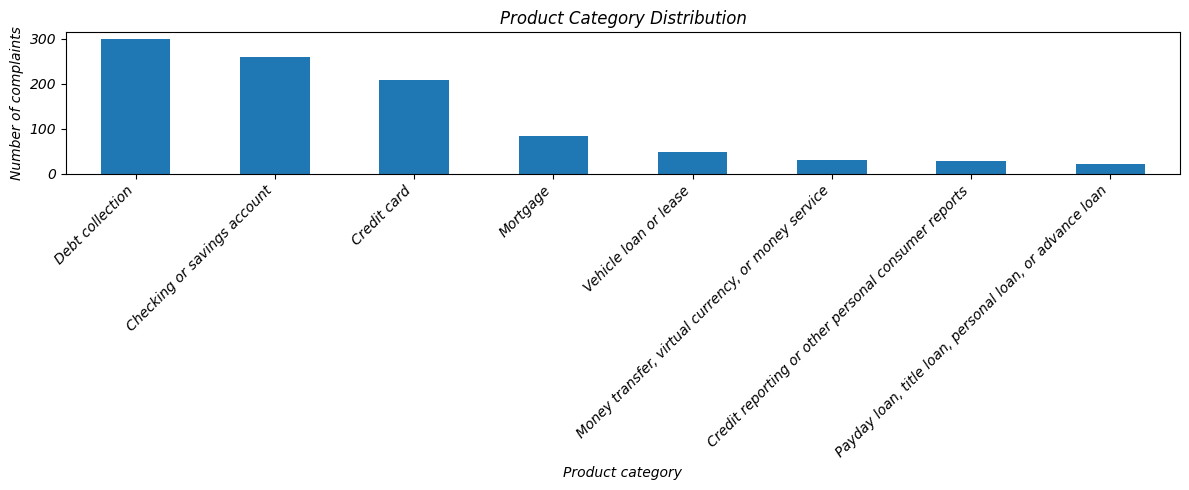

In [8]:
label_counts.plot(
    kind="bar",
    figsize=(12, 5),
    title="Product Category Distribution"
)

plt.xlabel("Product category")
plt.ylabel("Number of complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()